In [1]:
#source TFAvenv/bin/activate (launching and exiting the virtual environment containing the required modules, stored in the working directory)
#TFAvenv/bin/python your_script.py - for running a script in the virtual environment
#source deactivate

#import all the libraries needed
from import_dep import *
import importlib

# import my functions stored in the file 'functions' which can then be called with functions.function_name()
from SMU import SMU
import SMU_functions
importlib.reload(SMU_functions)  # Force reload to get updated function signatures
from SMU_functions import plot_IV, plot_CV, plot_resistance

# import custom plot style and colorbar functions
from plot_style import set_plot_style

# Define the path to the root directory containing all the XRD data
root_SMU = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/DR012'
output_SMU = '/Users/horatiocox/Desktop/RUG_postdoc/Experiments/Keithley/DR012/Output'

### Plotting and Output Variables 
export_data = True # set to True to export the data to a powerpoint presentation and as svg files and export to path_out
fig_format = 'png' # format of the figure to be saved

powerpoint_string = 'DR012_switching' # string to be added to the powerpoint file name

plot_transparency = True # set to True to make the data plots transparent

# Custom Scence style settings for figures
fig_size = set_plot_style(export_data = export_data, use_tex=True)
#plt.style.use(['science', 'grid', 'nature'])

plt.rcParams.update({
        # Line settings
        'lines.linewidth': 0.1,
        'lines.markersize': 0.1,

    })
    


In [2]:
# Test the SMU class by loading data
print("Testing SMU class...")

# Create SMU object
smu_DR012 = SMU(root_SMU)

# # Display basic information
# print(f"\nSMU object: {smu_DR012}")
# print(f"CV run numbers: {smu_DR012.cv_run_nums[:10]}...")  # Show first 10
# print(f"IV run numbers: {smu_DR012.iv_run_nums[:10]}...")  # Show first 10

# # Show sample CV data
# if smu_DR012.cv_data:
#     print(f"\nSample CV data (first file):")
#     print(smu_DR012.cv_data[0].head())

# # Show sample IV data  
# if smu_DR012.iv_data:
#     print(f"\nSample IV data (first file):")
#     print(smu_DR012.iv_data[0].head())

Testing SMU class...
Found 425 Excel files
Loaded 16 CV files and 409 IV files
Loaded 16 CV files and 409 IV files


# IV Plotting

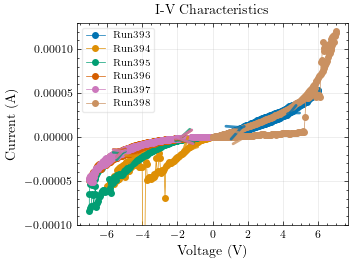

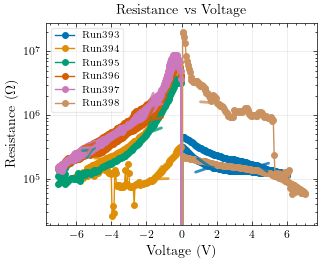

In [3]:
## IV Analysis with Direction Arrows

# Select specific runs for analysis using the built-in methods

#selected_iv_runs = [ 398, 399, 401, 402] 
#selected_iv_runs = [389, 390,392, 404, 398]
selected_iv_runs = [393, 394, 395, 396, 397, 398]

fig_iv = plot_IV([smu_DR012], run_nums=selected_iv_runs, 
                       log_plot=False, plot_arrows=True,
                        y_lim=[-0.00010, 0.00013],
                        line_width =0.5,
                       export_data=export_data, output_SMU=output_SMU)

fig_R = plot_resistance([smu_DR012], run_nums=selected_iv_runs, 
                       log_plot=True,
                       export_data=export_data, plot_arrows = True, output_SMU=output_SMU)



# CV Plotting

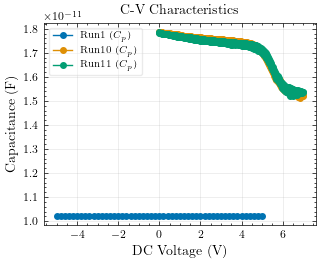


=== Testing Resistance Plot with Arrows ===


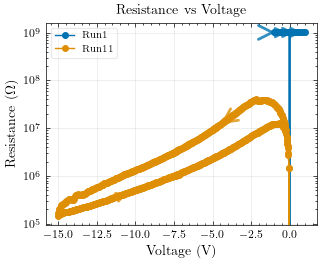

In [4]:
## CV Analysis
selected_cv_runs = [1, 10, 11] 

# Use get_cv_data and get_iv_data methods for clean data extraction
cv_data, cv_labels = smu_DR012.get_cv_data(run_nums=selected_cv_runs)

# Plot using the extracted data
fig_cv = plot_CV([smu_DR012], run_nums=selected_cv_runs, log_plot=False,
                 export_data=export_data, output_SMU=output_SMU)

## Resistance Analysis with Arrows
print("\n=== Testing Resistance Plot with Arrows ===")
selected_resistance_runs = [1, 11]  # Fewer runs for clearer visualization

# Test resistance plot with arrows
fig_r = plot_resistance([smu_DR012], run_nums=selected_resistance_runs, 
                       log_plot=True, plot_arrows=True,
                       export_data=export_data, output_SMU=output_SMU)



=== Testing x_lim masking with auto y-scaling ===
1. IV plot with x_lim=[0, 5] - y-axis should auto-scale to data in this range


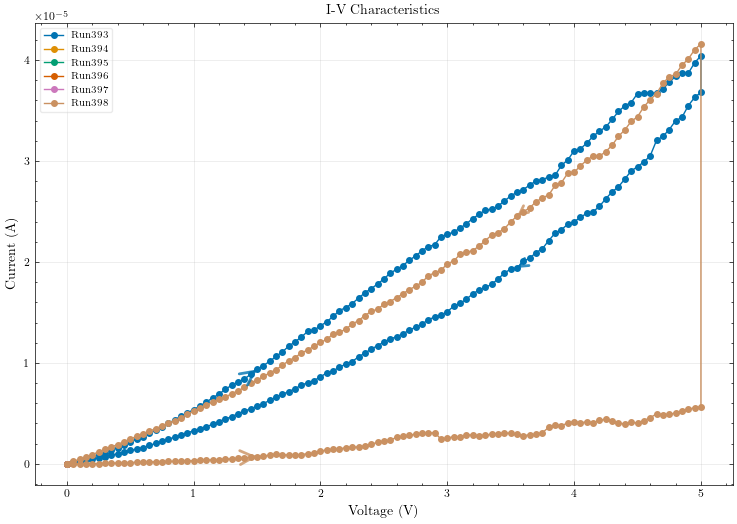

2. Resistance plot with x_lim=[-2, 2] - y-axis should auto-scale to resistance in this range


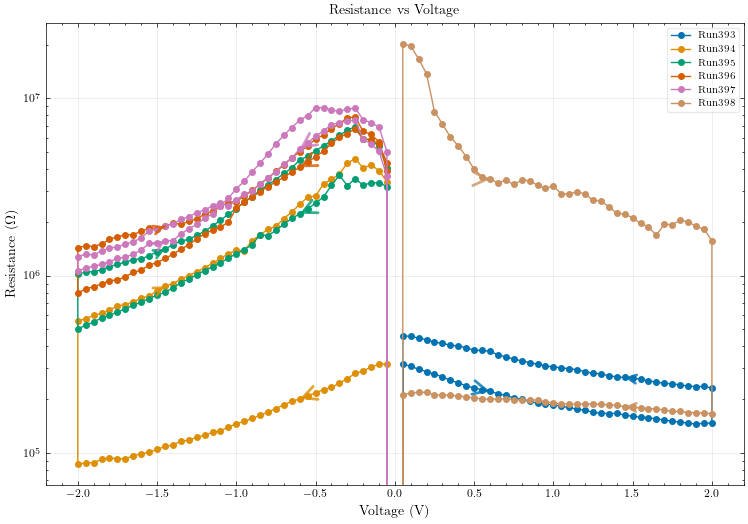

Now y-axis automatically scales to show only the data within the x_lim range!


In [5]:
## Testing x_lim Data Masking with Auto Y-scaling

print("=== Testing x_lim masking with auto y-scaling ===")

# Test 1: IV plot with x_lim masking (y should auto-scale to visible data)
print("1. IV plot with x_lim=[0, 5] - y-axis should auto-scale to data in this range")
fig_iv_masked = plot_IV([smu_DR012], run_nums=selected_iv_runs, 
                       x_lim=[0, 5],  # Only show 0 to 5V range - y will auto-scale
                       log_plot=False, plot_arrows=True,
                       export_data=False, output_SMU=output_SMU)

# Test 2: Resistance plot with x_lim masking
print("2. Resistance plot with x_lim=[-2, 2] - y-axis should auto-scale to resistance in this range")
fig_R_masked = plot_resistance([smu_DR012], run_nums=selected_iv_runs, 
                              x_lim=[-2, 2],  # Focus on -2V to +2V - y will auto-scale
                              log_plot=True, plot_arrows=True,
                              export_data=False, output_SMU=output_SMU)

print("Now y-axis automatically scales to show only the data within the x_lim range!")